# 04 - Avaliacao e Explicabilidade

## Objetivo
Aprofundar o modelo principal escolhido na etapa 4 (Regressao Logistica) para responder:
- Quao bom e o modelo final?
- Quais variaveis mais influenciam as decisoes?
- Por que o modelo acerta ou erra casos especificos?

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
shap.initjs()

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Carregar dados processados

In [2]:
base_path = '../data/processed'

X_train_raw = pd.read_csv(f'{base_path}/X_train_raw.csv')
X_test_raw = pd.read_csv(f'{base_path}/X_test_raw.csv')
y_train = pd.read_csv(f'{base_path}/y_train.csv').squeeze('columns')
y_test = pd.read_csv(f'{base_path}/y_test.csv').squeeze('columns')

print(f'X_train_raw: {X_train_raw.shape} | X_test_raw: {X_test_raw.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')

X_train_raw: (455, 30) | X_test_raw: (114, 30)
y_train: (455,) | y_test: (114,)


## 2. Recriar scaler e modelo final

Recriamos o pipeline vencedor da etapa 4 para manter consistencia: StandardScaler + Regressao Logistica.

In [3]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print('Pipeline recriado com sucesso.')

Pipeline recriado com sucesso.


## 3. Metricas finais do modelo

In [4]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

metricas = pd.DataFrame([
    {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_maligno': precision_score(y_test, y_pred, pos_label=1),
        'recall_maligno': recall_score(y_test, y_pred, pos_label=1),
        'f1_maligno': f1_score(y_test, y_pred, pos_label=1)
    }
]).round(4)

metricas

,accuracy,precision_maligno,recall_maligno,f1_maligno
0,0.9649,0.975,0.9286,0.9512


In [5]:
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



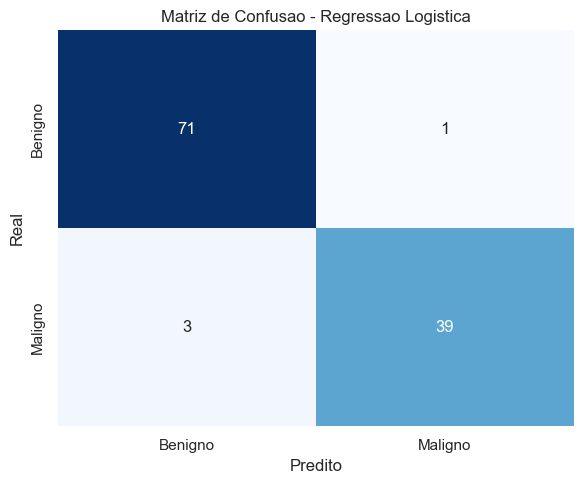

In [6]:
os.makedirs('../outputs/figures', exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusao - Regressao Logistica')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.xticks([0.5, 1.5], ['Benigno', 'Maligno'])
plt.yticks([0.5, 1.5], ['Benigno', 'Maligno'])
plt.tight_layout()
plt.savefig('../outputs/figures/matriz_confusao_logreg.png', dpi=150)
plt.show()

## 4. Feature importance via coeficientes

Como a Regressao Logistica foi treinada com dados padronizados, a magnitude dos coeficientes pode ser usada para comparar importancia relativa das variaveis.

- Coeficiente positivo: empurra a predicao para maligno
- Coeficiente negativo: empurra a predicao para benigno

In [7]:
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coeficiente': model.coef_[0]
})
coef_df['importance_abs'] = coef_df['coeficiente'].abs()
coef_df['direcao'] = np.where(coef_df['coeficiente'] >= 0, 'Puxa para maligno', 'Puxa para benigno')
coef_df = coef_df.sort_values('importance_abs', ascending=False).reset_index(drop=True)

coef_df.head(15)

,feature,coeficiente,importance_abs,direcao
0,texture_worst,1.434093,1.434093,Puxa para maligno
1,radius_se,1.233325,1.233325,Puxa para maligno
2,symmetry_worst,1.061264,1.061264,Puxa para maligno
3,concave points_mean,0.952813,0.952813,Puxa para maligno
4,concavity_worst,0.911406,0.911406,Puxa para maligno
5,area_se,0.909029,0.909029,Puxa para maligno
6,compactness_se,-0.906925,0.906925,Puxa para benigno
7,area_worst,0.900477,0.900477,Puxa para maligno
8,radius_worst,0.896968,0.896968,Puxa para maligno
9,concavity_mean,0.782298,0.782298,Puxa para maligno


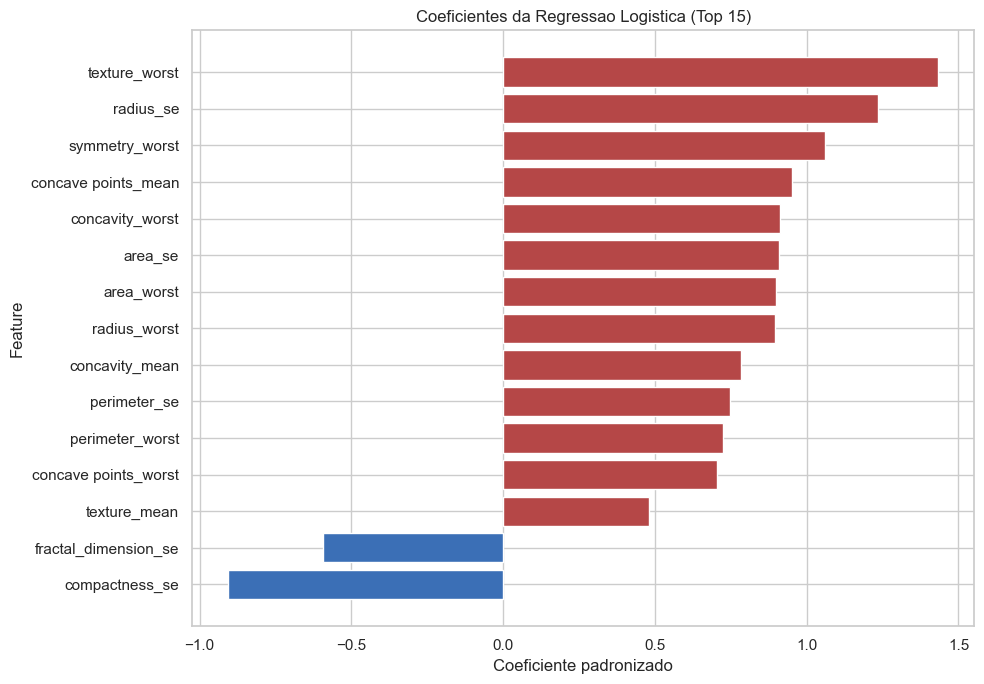

In [8]:
top_features = coef_df.head(15).sort_values('coeficiente')
colors = ['#b54747' if value > 0 else '#3b6fb6' for value in top_features['coeficiente']]

plt.figure(figsize=(10, 7))
plt.barh(top_features['feature'], top_features['coeficiente'], color=colors)
plt.title('Coeficientes da Regressao Logistica (Top 15)')
plt.xlabel('Coeficiente padronizado')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_logreg.png', dpi=150)
plt.show()

## 5. SHAP global

O SHAP mostra quanto cada variavel contribui para empurrar a predicao para maligno ou benigno.

- Grafico bar: importancia media global
- Grafico beeswarm: distribuicao do impacto por amostra

In [9]:
explainer = shap.Explainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

print('SHAP calculado com sucesso.')

SHAP calculado com sucesso.


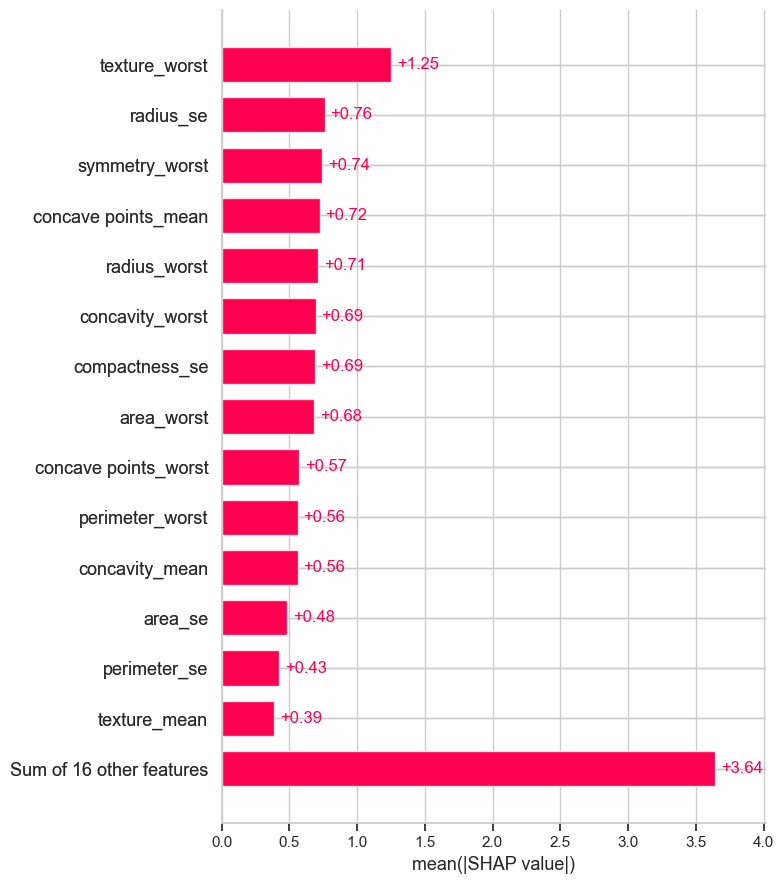

In [10]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_bar_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

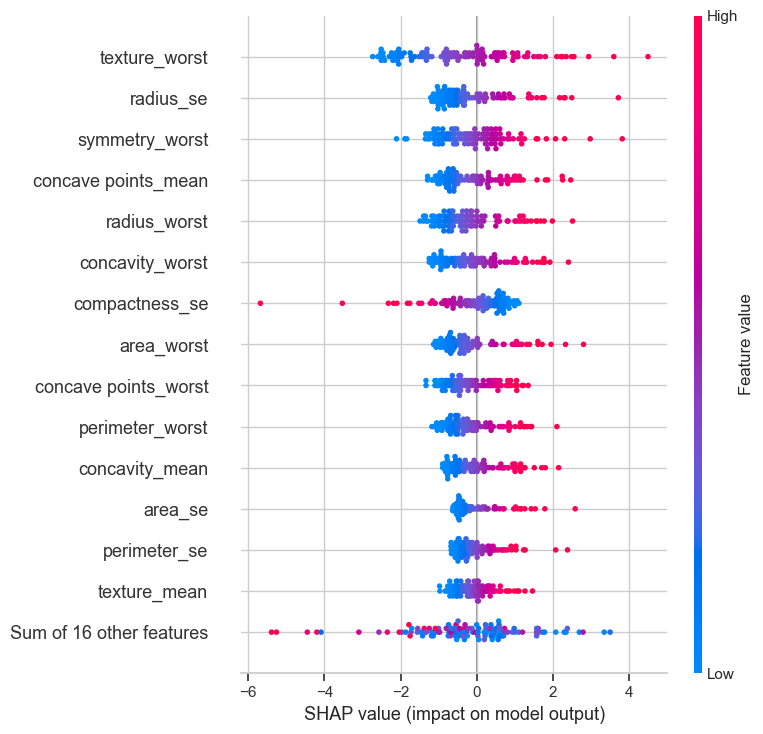

In [11]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_beeswarm_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Analise de erros

Vamos identificar falsos negativos e falsos positivos para discutir limites do modelo.

In [12]:
analise_erros = X_test_raw.copy()
analise_erros['y_real'] = y_test.values
analise_erros['y_pred'] = y_pred
analise_erros['prob_maligno'] = y_proba

falsos_negativos = analise_erros[(analise_erros['y_real'] == 1) & (analise_erros['y_pred'] == 0)].copy()
falsos_positivos = analise_erros[(analise_erros['y_real'] == 0) & (analise_erros['y_pred'] == 1)].copy()

resumo_erros = pd.DataFrame({
    'tipo_erro': ['Falso Negativo', 'Falso Positivo'],
    'quantidade': [len(falsos_negativos), len(falsos_positivos)]
})

resumo_erros

,tipo_erro,quantidade
0,Falso Negativo,3
1,Falso Positivo,1


In [13]:
print('Falsos negativos:')
display(falsos_negativos[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'prob_maligno']].head())

print('Falsos positivos:')
display(falsos_positivos[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'prob_maligno']].head())

Falsos negativos:


,radius_mean,texture_mean,perimeter_mean,area_mean,concavity_mean,prob_maligno
16,13.80,15.79,90.43,584.1,0.07789,0.061429
87,14.22,23.12,94.37,609.9,0.19810,0.314532
112,15.12,16.68,98.78,716.6,0.07550,0.491610


Falsos positivos:


,radius_mean,texture_mean,perimeter_mean,area_mean,concavity_mean,prob_maligno
4,13.38,30.72,86.34,557.2,0.02819,0.509155


## 7. SHAP local em casos especificos

Vamos explicar:
- um caso corretamente previsto como maligno
- um falso negativo, se existir

In [14]:
indices_tp = analise_erros[(analise_erros['y_real'] == 1) & (analise_erros['y_pred'] == 1)].index.tolist()
indices_fn = falsos_negativos.index.tolist()

indice_tp = indices_tp[0] if indices_tp else None
indice_fn = indices_fn[0] if indices_fn else None

print(f'Indice TP selecionado: {indice_tp}')
print(f'Indice FN selecionado: {indice_fn}')

Indice TP selecionado: 1
Indice FN selecionado: 16


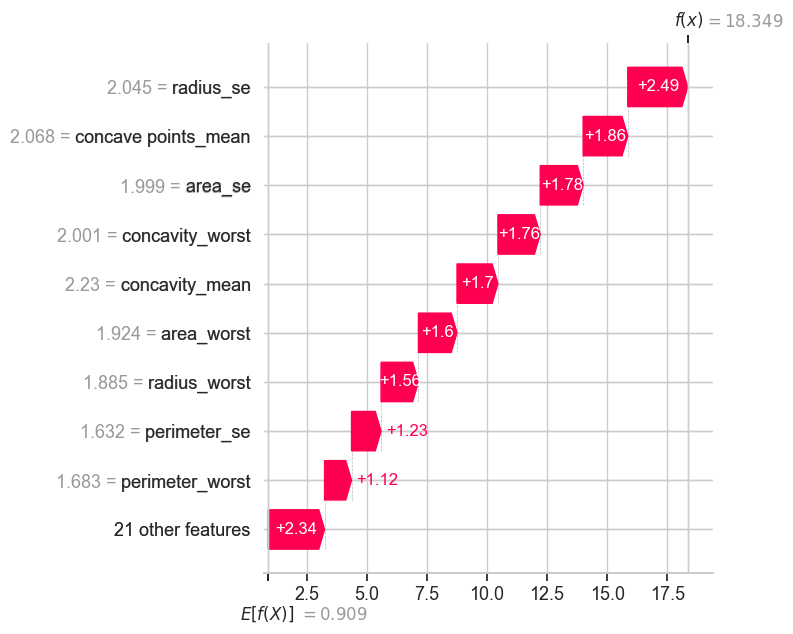

In [15]:
if indice_tp is not None:
    pos_tp = X_test_scaled.index.get_loc(indice_tp)
    shap.plots.waterfall(shap_values[pos_tp], max_display=10, show=False)
    plt.tight_layout()
    plt.savefig('../outputs/figures/shap_local_true_positive.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nao foi encontrado verdadeiro positivo para explicacao local.')

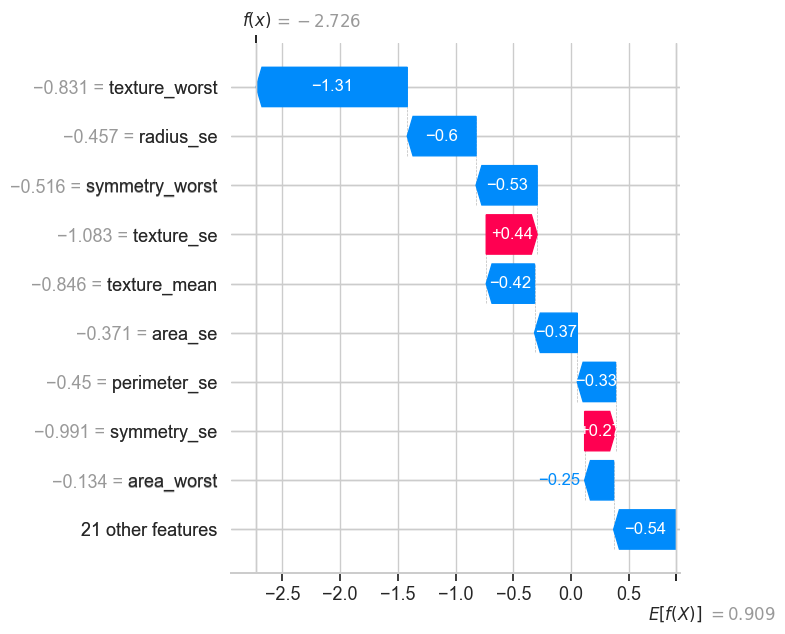

In [16]:
if indice_fn is not None:
    pos_fn = X_test_scaled.index.get_loc(indice_fn)
    shap.plots.waterfall(shap_values[pos_fn], max_display=10, show=False)
    plt.tight_layout()
    plt.savefig('../outputs/figures/shap_local_false_negative.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nao houve falso negativo neste conjunto.')

## 8. Salvar artefatos reutilizaveis



In [17]:
os.makedirs('../outputs/models', exist_ok=True)

joblib.dump(model, '../outputs/models/modelo_logistico_final.pkl')
joblib.dump(scaler, '../outputs/models/scaler_logistico_final.pkl')
metricas.to_csv('../outputs/models/metricas_logreg.csv', index=False)
coef_df.to_csv('../outputs/models/feature_importance_logreg.csv', index=False)
resumo_erros.to_csv('../outputs/models/resumo_erros_logreg.csv', index=False)

print('Artefatos salvos com sucesso.')

Artefatos salvos com sucesso.


## Conclusao

A etapa 5 consolida o modelo final e mostra nao apenas o desempenho, mas tambem a logica por tras das decisoes e dos erros.



## 9. Ajuste controlado sem fugir do escopo

Para reduzir erros criticos (falsos negativos), vamos testar somente variacoes da Regressao Logistica:

- Baseline (modelo atual)
- Regressao Logistica com `class_weight='balanced'`
- Diferentes limiares de decisao (0.50, 0.45, 0.40, 0.35)

Obs: isso continua dentro do escopo do Tech Challenge, pois foi mantido o mesmo problema e a mesma abordagem de classificacao supervisionada.

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Modelo com peso balanceado para tentar reduzir falsos negativos
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

proba_base = model.predict_proba(X_test_scaled)[:, 1]
proba_bal = model_balanced.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.50, 0.45, 0.40, 0.35]
rows = []

for t in thresholds:
    pred_base = (proba_base >= t).astype(int)
    pred_bal = (proba_bal >= t).astype(int)

    for nome, pred in [('baseline', pred_base), ('balanced', pred_bal)]:
        tn = int(((y_test == 0) & (pred == 0)).sum())
        fp = int(((y_test == 0) & (pred == 1)).sum())
        fn = int(((y_test == 1) & (pred == 0)).sum())
        tp = int(((y_test == 1) & (pred == 1)).sum())

        rows.append({
            'modelo': nome,
            'threshold': t,
            'accuracy': round(accuracy_score(y_test, pred), 4),
            'precision_maligno': round(precision_score(y_test, pred, pos_label=1, zero_division=0), 4),
            'recall_maligno': round(recall_score(y_test, pred, pos_label=1, zero_division=0), 4),
            'f1_maligno': round(f1_score(y_test, pred, pos_label=1, zero_division=0), 4),
            'falsos_negativos': fn,
            'falsos_positivos': fp,
            'tp': tp,
            'tn': tn
        })

df_tuning = pd.DataFrame(rows)

# Ordenacao priorizando menor FN, depois maior F1, depois maior recall, depois maior accuracy
df_tuning_ranked = df_tuning.sort_values(
    by=['falsos_negativos', 'f1_maligno', 'recall_maligno', 'accuracy'],
    ascending=[True, False, False, False]
).reset_index(drop=True)

df_tuning_ranked

,modelo,threshold,accuracy,precision_maligno,recall_maligno,f1_maligno,falsos_negativos,falsos_positivos,tp,tn
0,balanced,0.50,0.9737,0.9756,0.9524,0.9639,2,1,40,71
1,baseline,0.45,0.9737,0.9756,0.9524,0.9639,2,1,40,71
2,balanced,0.45,0.9737,0.9756,0.9524,0.9639,2,1,40,71
3,baseline,0.40,0.9737,0.9756,0.9524,0.9639,2,1,40,71
4,balanced,0.40,0.9737,0.9756,0.9524,0.9639,2,1,40,71
5,baseline,0.35,0.9737,0.9756,0.9524,0.9639,2,1,40,71
6,balanced,0.35,0.9737,0.9756,0.9524,0.9639,2,1,40,71
7,baseline,0.50,0.9649,0.9750,0.9286,0.9512,3,1,39,71


Melhor ajuste encontrado (criterio: menor FN, maior F1):
modelo               balanced
threshold                 0.5
accuracy               0.9737
precision_maligno      0.9756
recall_maligno         0.9524
f1_maligno             0.9639
falsos_negativos            2
falsos_positivos            1
tp                         40
tn                         71
Name: 0, dtype: object


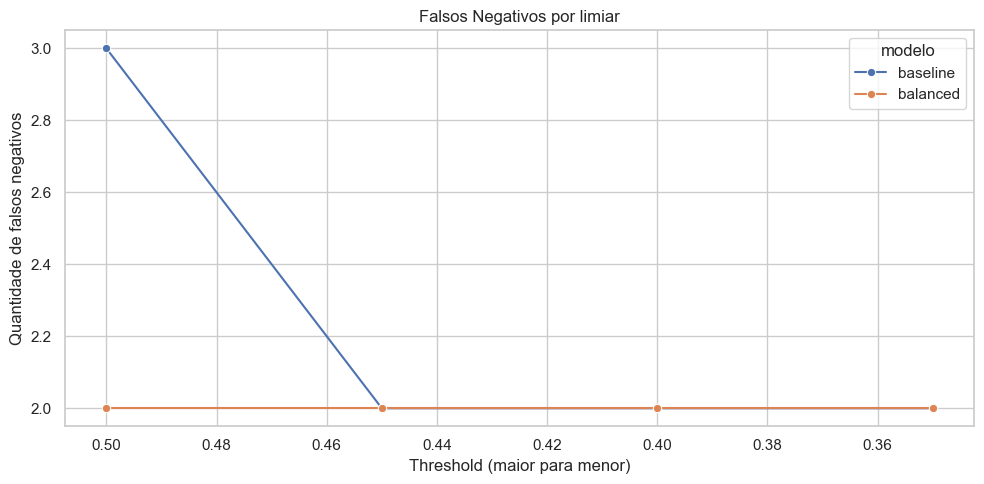

In [19]:
melhor_ajuste = df_tuning_ranked.iloc[0]
print('Melhor ajuste encontrado (criterio: menor FN, maior F1):')
print(melhor_ajuste)

plt.figure(figsize=(10, 5))
plot_df = df_tuning[df_tuning['threshold'].isin([0.50, 0.45, 0.40, 0.35])].copy()
sns.lineplot(data=plot_df, x='threshold', y='falsos_negativos', hue='modelo', marker='o')
plt.gca().invert_xaxis()
plt.title('Falsos Negativos por limiar')
plt.xlabel('Threshold (maior para menor)')
plt.ylabel('Quantidade de falsos negativos')
plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/tuning_falsos_negativos_logreg.png', dpi=150)
plt.show()

In [20]:
os.makedirs('../outputs/models', exist_ok=True)
df_tuning_ranked.to_csv('../outputs/models/tuning_logreg_threshold_classweight.csv', index=False)
print('Tabela de tuning salva em outputs/models/tuning_logreg_threshold_classweight.csv')

Tabela de tuning salva em outputs/models/tuning_logreg_threshold_classweight.csv


In [21]:
# Persistir modelo ajustado vencedor da tentativa de correcao
joblib.dump(model_balanced, '../outputs/models/modelo_logistico_tuned_balanced.pkl')

melhor_ajuste_df = pd.DataFrame([melhor_ajuste])
melhor_ajuste_df.to_csv('../outputs/models/melhor_ajuste_logreg.csv', index=False)

print('Modelo tuned salvo em outputs/models/modelo_logistico_tuned_balanced.pkl')
print('Resumo do melhor ajuste salvo em outputs/models/melhor_ajuste_logreg.csv')

Modelo tuned salvo em outputs/models/modelo_logistico_tuned_balanced.pkl
Resumo do melhor ajuste salvo em outputs/models/melhor_ajuste_logreg.csv
